# Direct Mix

use the train set which just **simply mix** the dft train set and exp train set.

use the best model **XGBoost** which we get from previous steps.

In [2]:
import os
import sys
import pandas as pd
import numpy as np
np.random.seed(42)
current_path = os.getcwd()
current_path

'c:\\Users\\Fortyfour\\Desktop\\graduation_design\\Scripts_git\\MixedDataTrain'

In [3]:
file_path = os.path.join(current_path, 'DirectMix')
os.makedirs(file_path, exist_ok=True)

In [4]:
# Set random seed for reproducibility
RANDOM_SEED = 42
# 
FIG_SHOW = False

In [5]:
# To import the custom module from a specific path
sys.path.insert(0, os.path.join(current_path, '../'))
# Importing the custom module
from Utools.draw import plot_feature_importance, plot_feature_importance
from Utools.SingleModel import SingleModel

In [6]:
# Load data
file_dir = os.path.join(current_path, '../Data/composition_data/feature_data')
# dft data
dft_train = pd.read_csv(os.path.join(file_dir, 'dft', 'train.csv'))
dft_test = pd.read_csv(os.path.join(file_dir, 'dft', 'test.csv'))
# exp data
exp_train = pd.read_csv(os.path.join(file_dir, 'exp', 'train.csv'))
exp_test = pd.read_csv(os.path.join(file_dir, 'exp', 'test.csv'))

dft_train_X = dft_train.drop(columns=['composition', 'band_gap'])
dft_train_y = dft_train['band_gap']
exp_train_X = exp_train.drop(columns=['composition', 'band_gap'])
exp_train_y = exp_train['band_gap']
dft_test_X = dft_test.drop(columns=['composition', 'band_gap'])
dft_test_y = dft_test['band_gap']
exp_test_X = exp_test.drop(columns=['composition', 'band_gap'])
exp_test_y = exp_test['band_gap']

# Mixed train set
train_X = pd.concat([dft_train_X, exp_train_X], axis=0, ignore_index=True)
train_y = pd.concat([dft_train_y, exp_train_y], axis=0, ignore_index=True)

# Mixed test set
# due to the number of test samples in dft and exp have a large difference
# so we resample the dft test set:   dft:exp = 2:1
dft_test_X_subset = dft_test_X.sample(n=len(exp_test_X) * 2, random_state=RANDOM_SEED)
dft_test_y_subset = dft_test_y.loc[dft_test_X_subset.index]
# mix
test_X = pd.concat([dft_test_X_subset, exp_test_X], ignore_index=True)
test_y = pd.concat([dft_test_y_subset, exp_test_y], ignore_index=True)



In [7]:
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((25245, 132), (25245,), (2271, 132), (2271,))

## Hyper Parameters Search

In [8]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV

In [ ]:
# using grid search to find the best hyperparameters 
print(f"Hyper Parameters optimization begin...")


# create a pipeline
xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(objective='reg:squarederror', random_state=RANDOM_SEED, n_jobs=-1) )
]) 
# define the parameter grid for the XGBoost model(total 960 combinations)
# cpu = 60, run_time = 35min
param_grid = {
    'xgb__n_estimators': [200, 500],
    'xgb__max_depth': [3, 5, 6, 7, 9, 10],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'xgb__subsample': [0.7, 1.0],
    'xgb__colsample_bytree': [0.7, 1.0],
    'xgb__lambda': [0.5, 1],
    'xgb__alpha': [0, 0.5]
}

# create a KFold object for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# n_iters=6, runtime=8s
# create a GridSearchCV object
grid_search = GridSearchCV(
    estimator=xgb_pipe, 
    param_grid=param_grid, 
    scoring='neg_mean_squared_error', 
    cv=kf, 
    n_jobs=-1, 
    verbose=1,
    return_train_score=True)

# fit the model to the training data
grid_search.fit(train_X, train_y)

In [ ]:
# get the best hyperparameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")
best_score = np.sqrt(-grid_search.best_score_)
print(f"Best Cross-Validation RMSE: {best_score:.4f}")

# create a DataFrame to store the results
results = pd.DataFrame(grid_search.cv_results_)
results['test_rmse'] = np.sqrt(-results['mean_test_score'])
results['train_rmse'] = np.sqrt(-results['mean_train_score'])
# sort the results by test RMSE
results_sorted = results.sort_values('test_rmse')
results_sorted = results_sorted[['rank_test_score', 'param_xgb__n_estimators', 'param_xgb__max_depth',
                                 'param_xgb__learning_rate', 'param_xgb__subsample',
                                 'param_xgb__colsample_bytree', 'param_xgb__lambda', 'param_xgb__alpha',
                                 'train_rmse', 'test_rmse']]

# save the results to a csv file
results_sorted.to_csv(os.path.join(file_path, 'hp_search_results.csv'), index=False)
results_sorted.head()

## Model Train

####################################################################################################
[DFT - Direct Mix XGBoost] Training Direct Mix XGBoost on Mix data:
----------------------------------------------------------------------------------------------------
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............. (step 2 of 2) Processing model, total=   4.8s
Model training completed!
[Train_error] Evaluating Direct Mix XGBoost on train set:


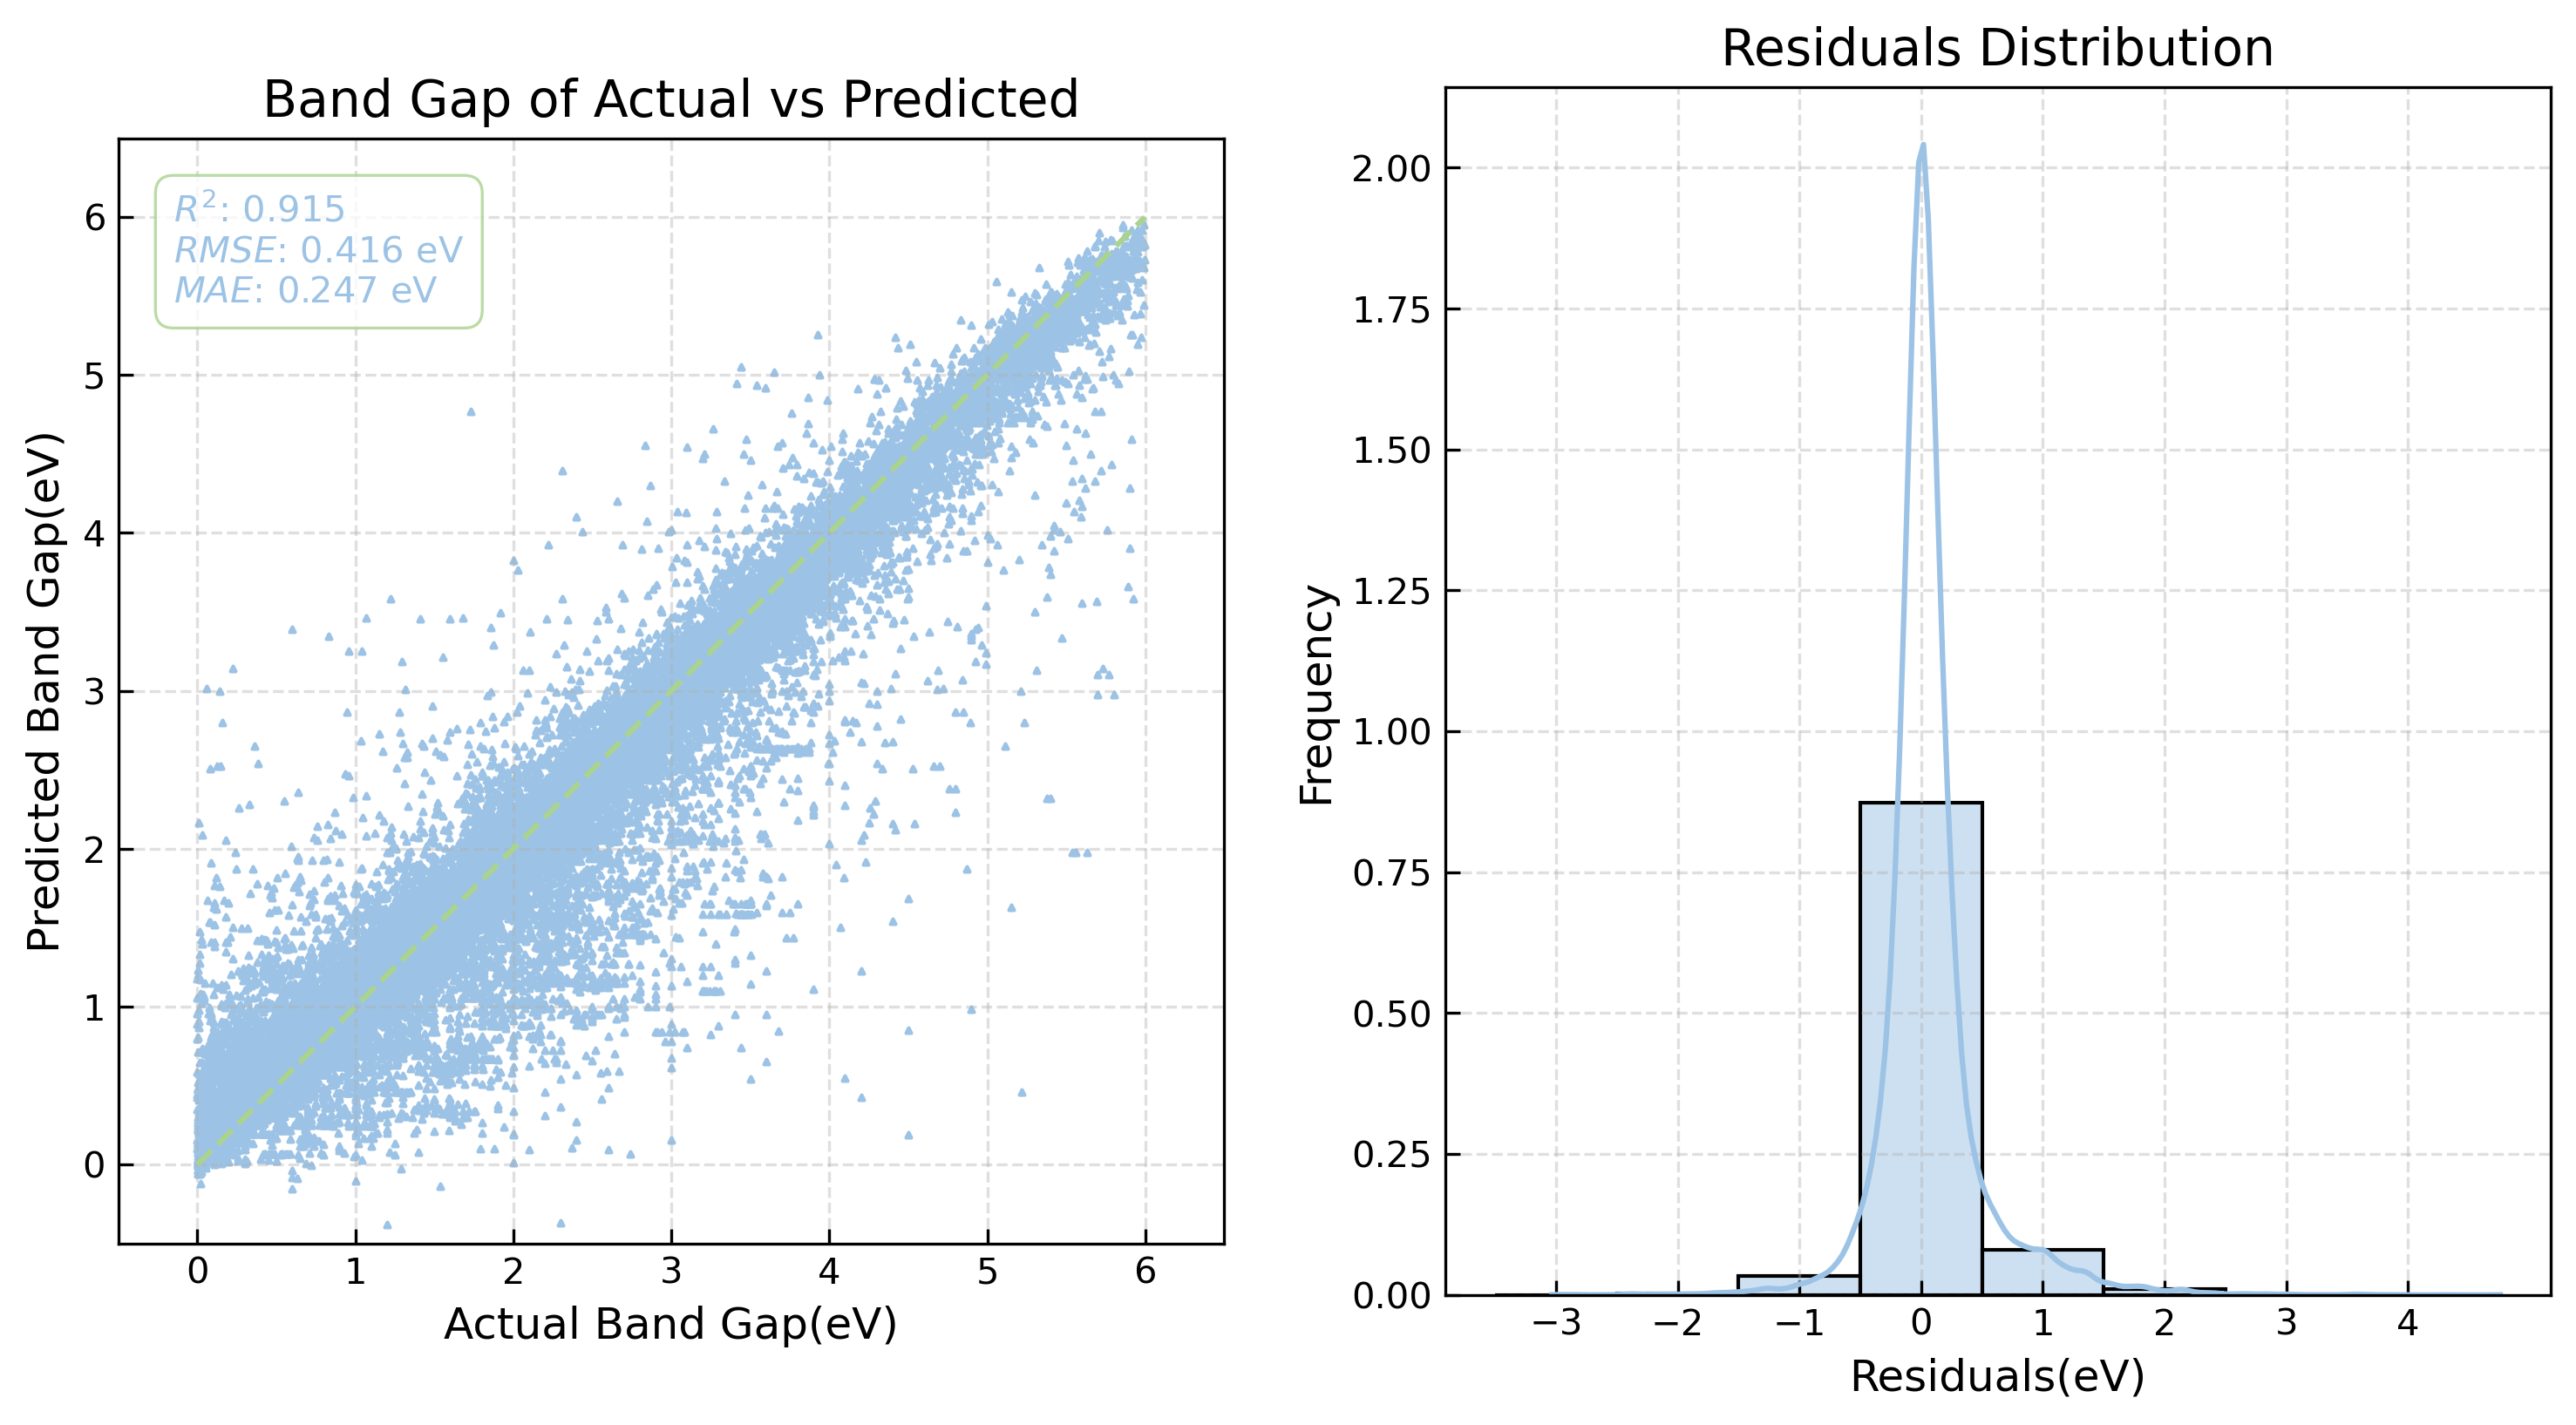


Model Evaluation Results:
Test set size: 25245
Test set: R²: 0.9151 RMSE: 0.4161 MAE: 0.2465 MAPE: 256.4091%
[Test MIX -> DFT] Evaluating Direct Mix XGBoost on DFT test set:


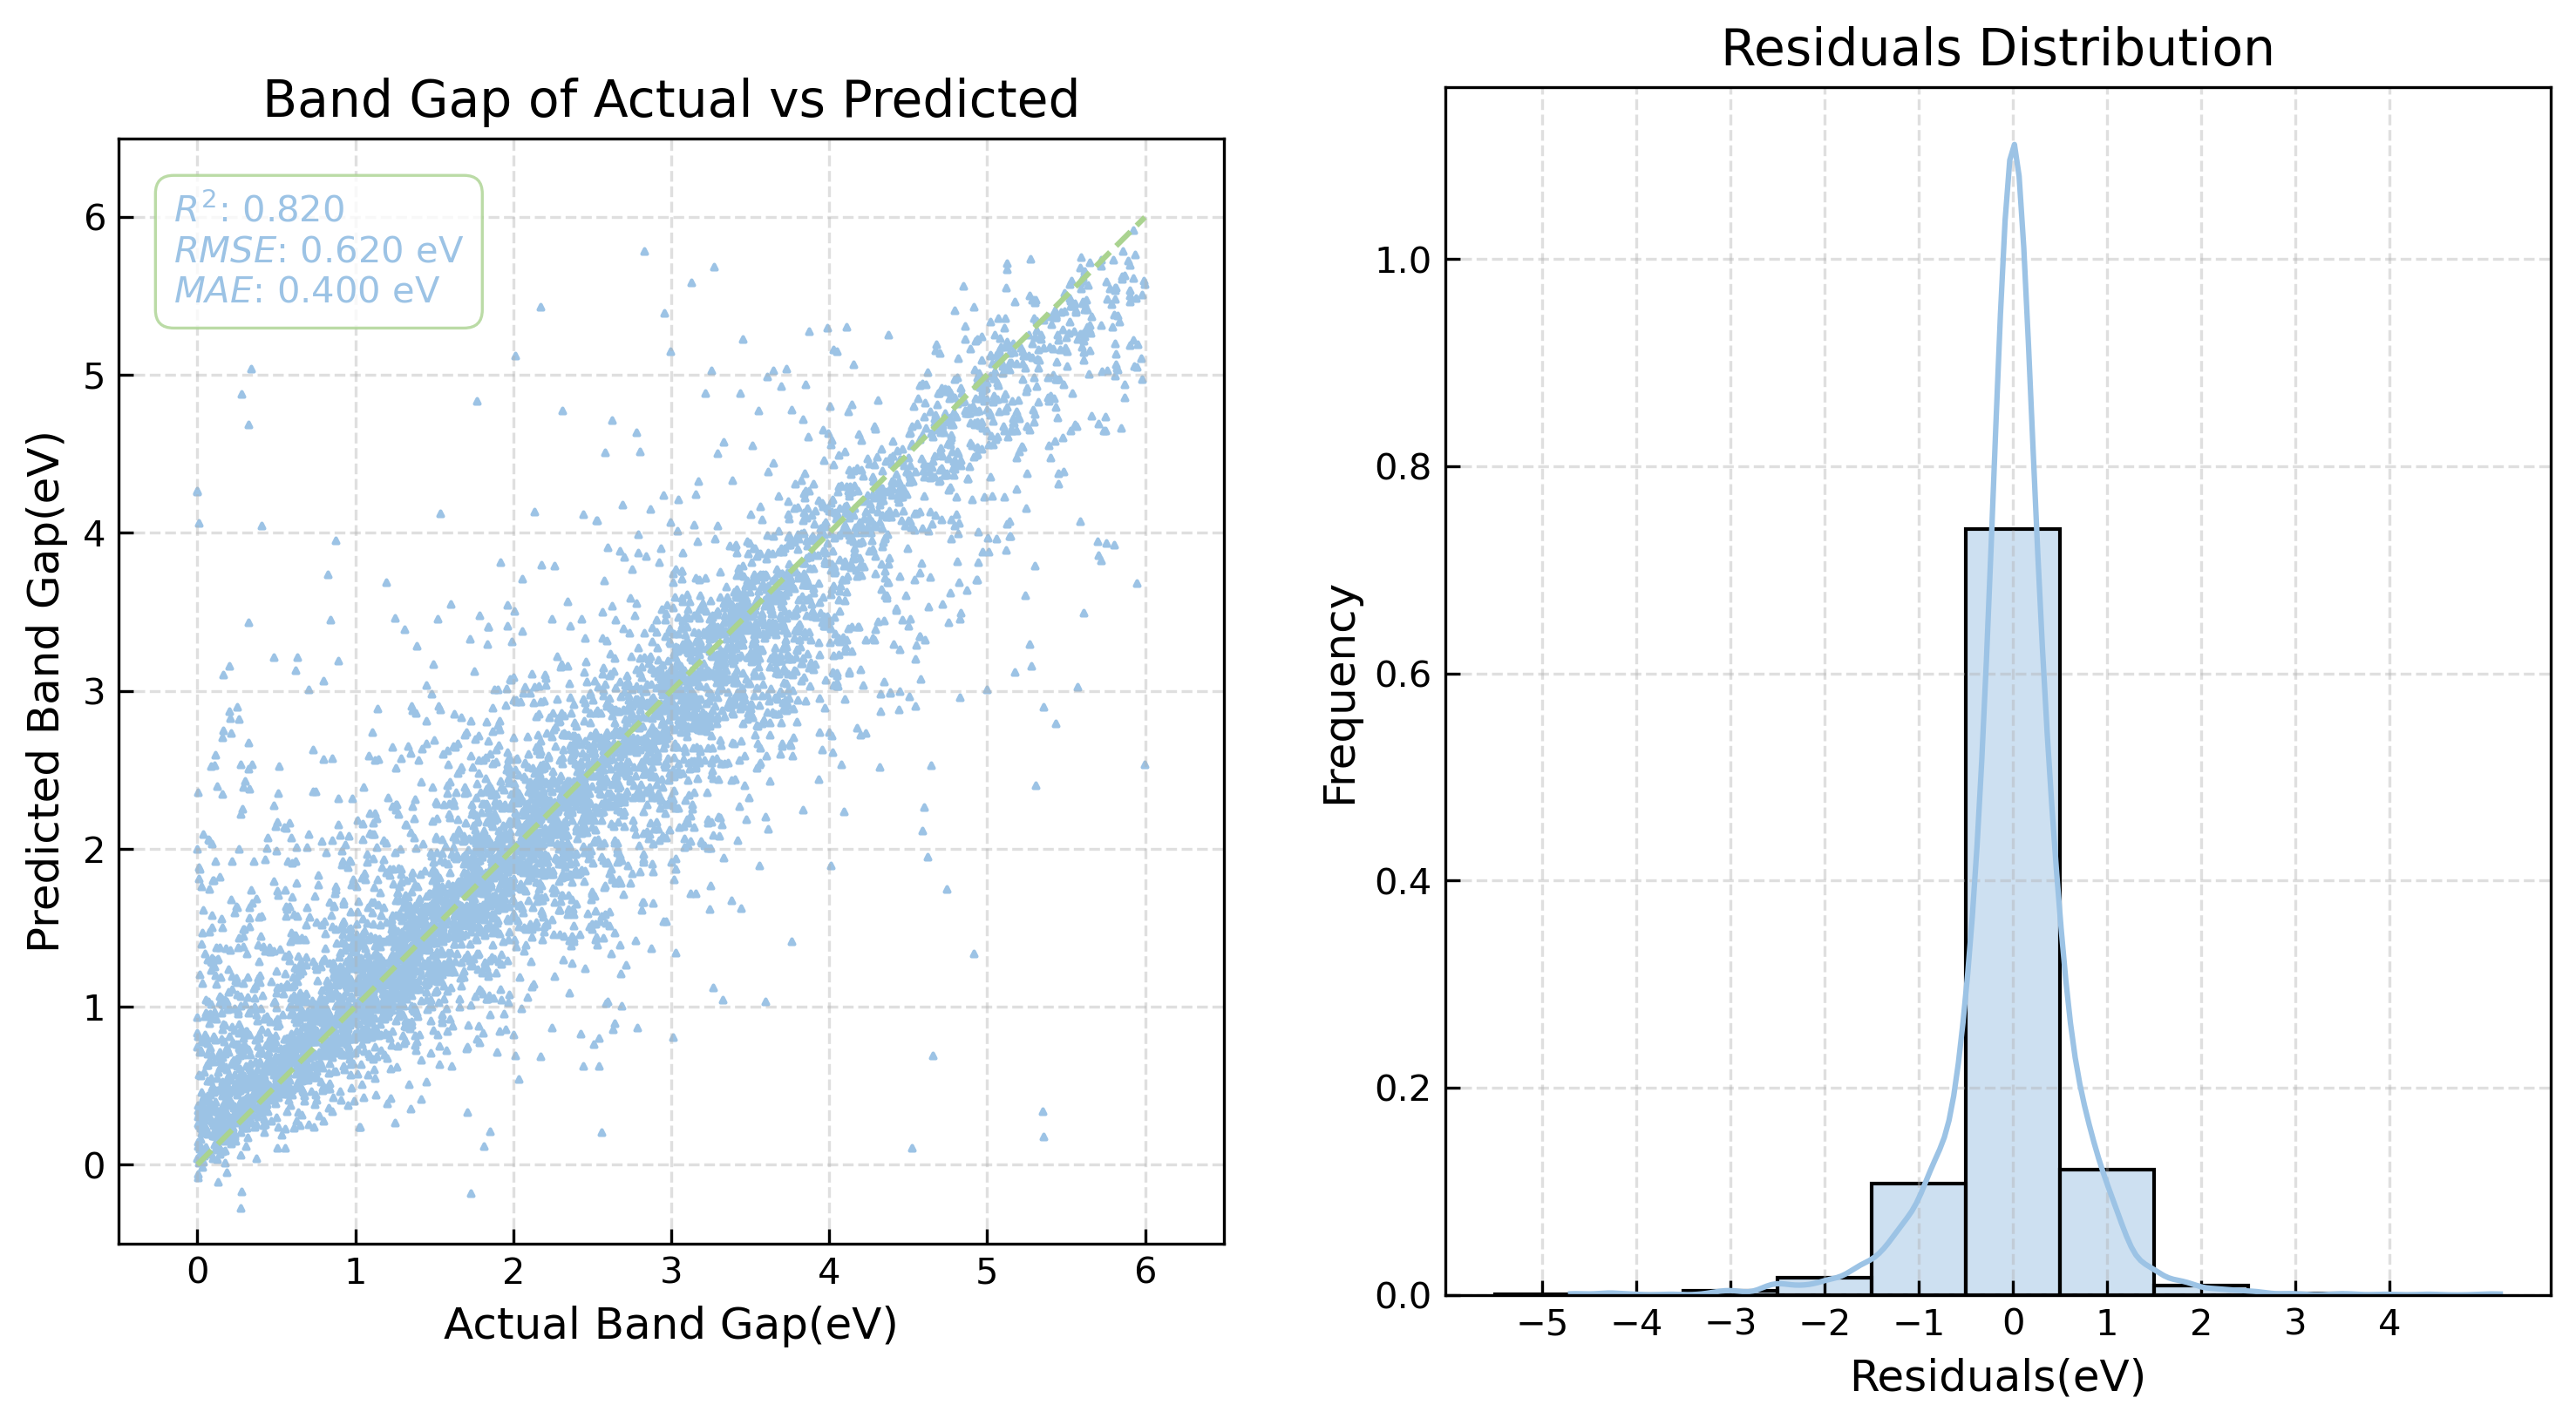


Model Evaluation Results:
Test set size: 5556
Test set: R²: 0.8200 RMSE: 0.6198 MAE: 0.4005 MAPE: 1689.3763%
[Test MIX -> EXP] Evaluating Direct Mix XGBoost on EXP test set:


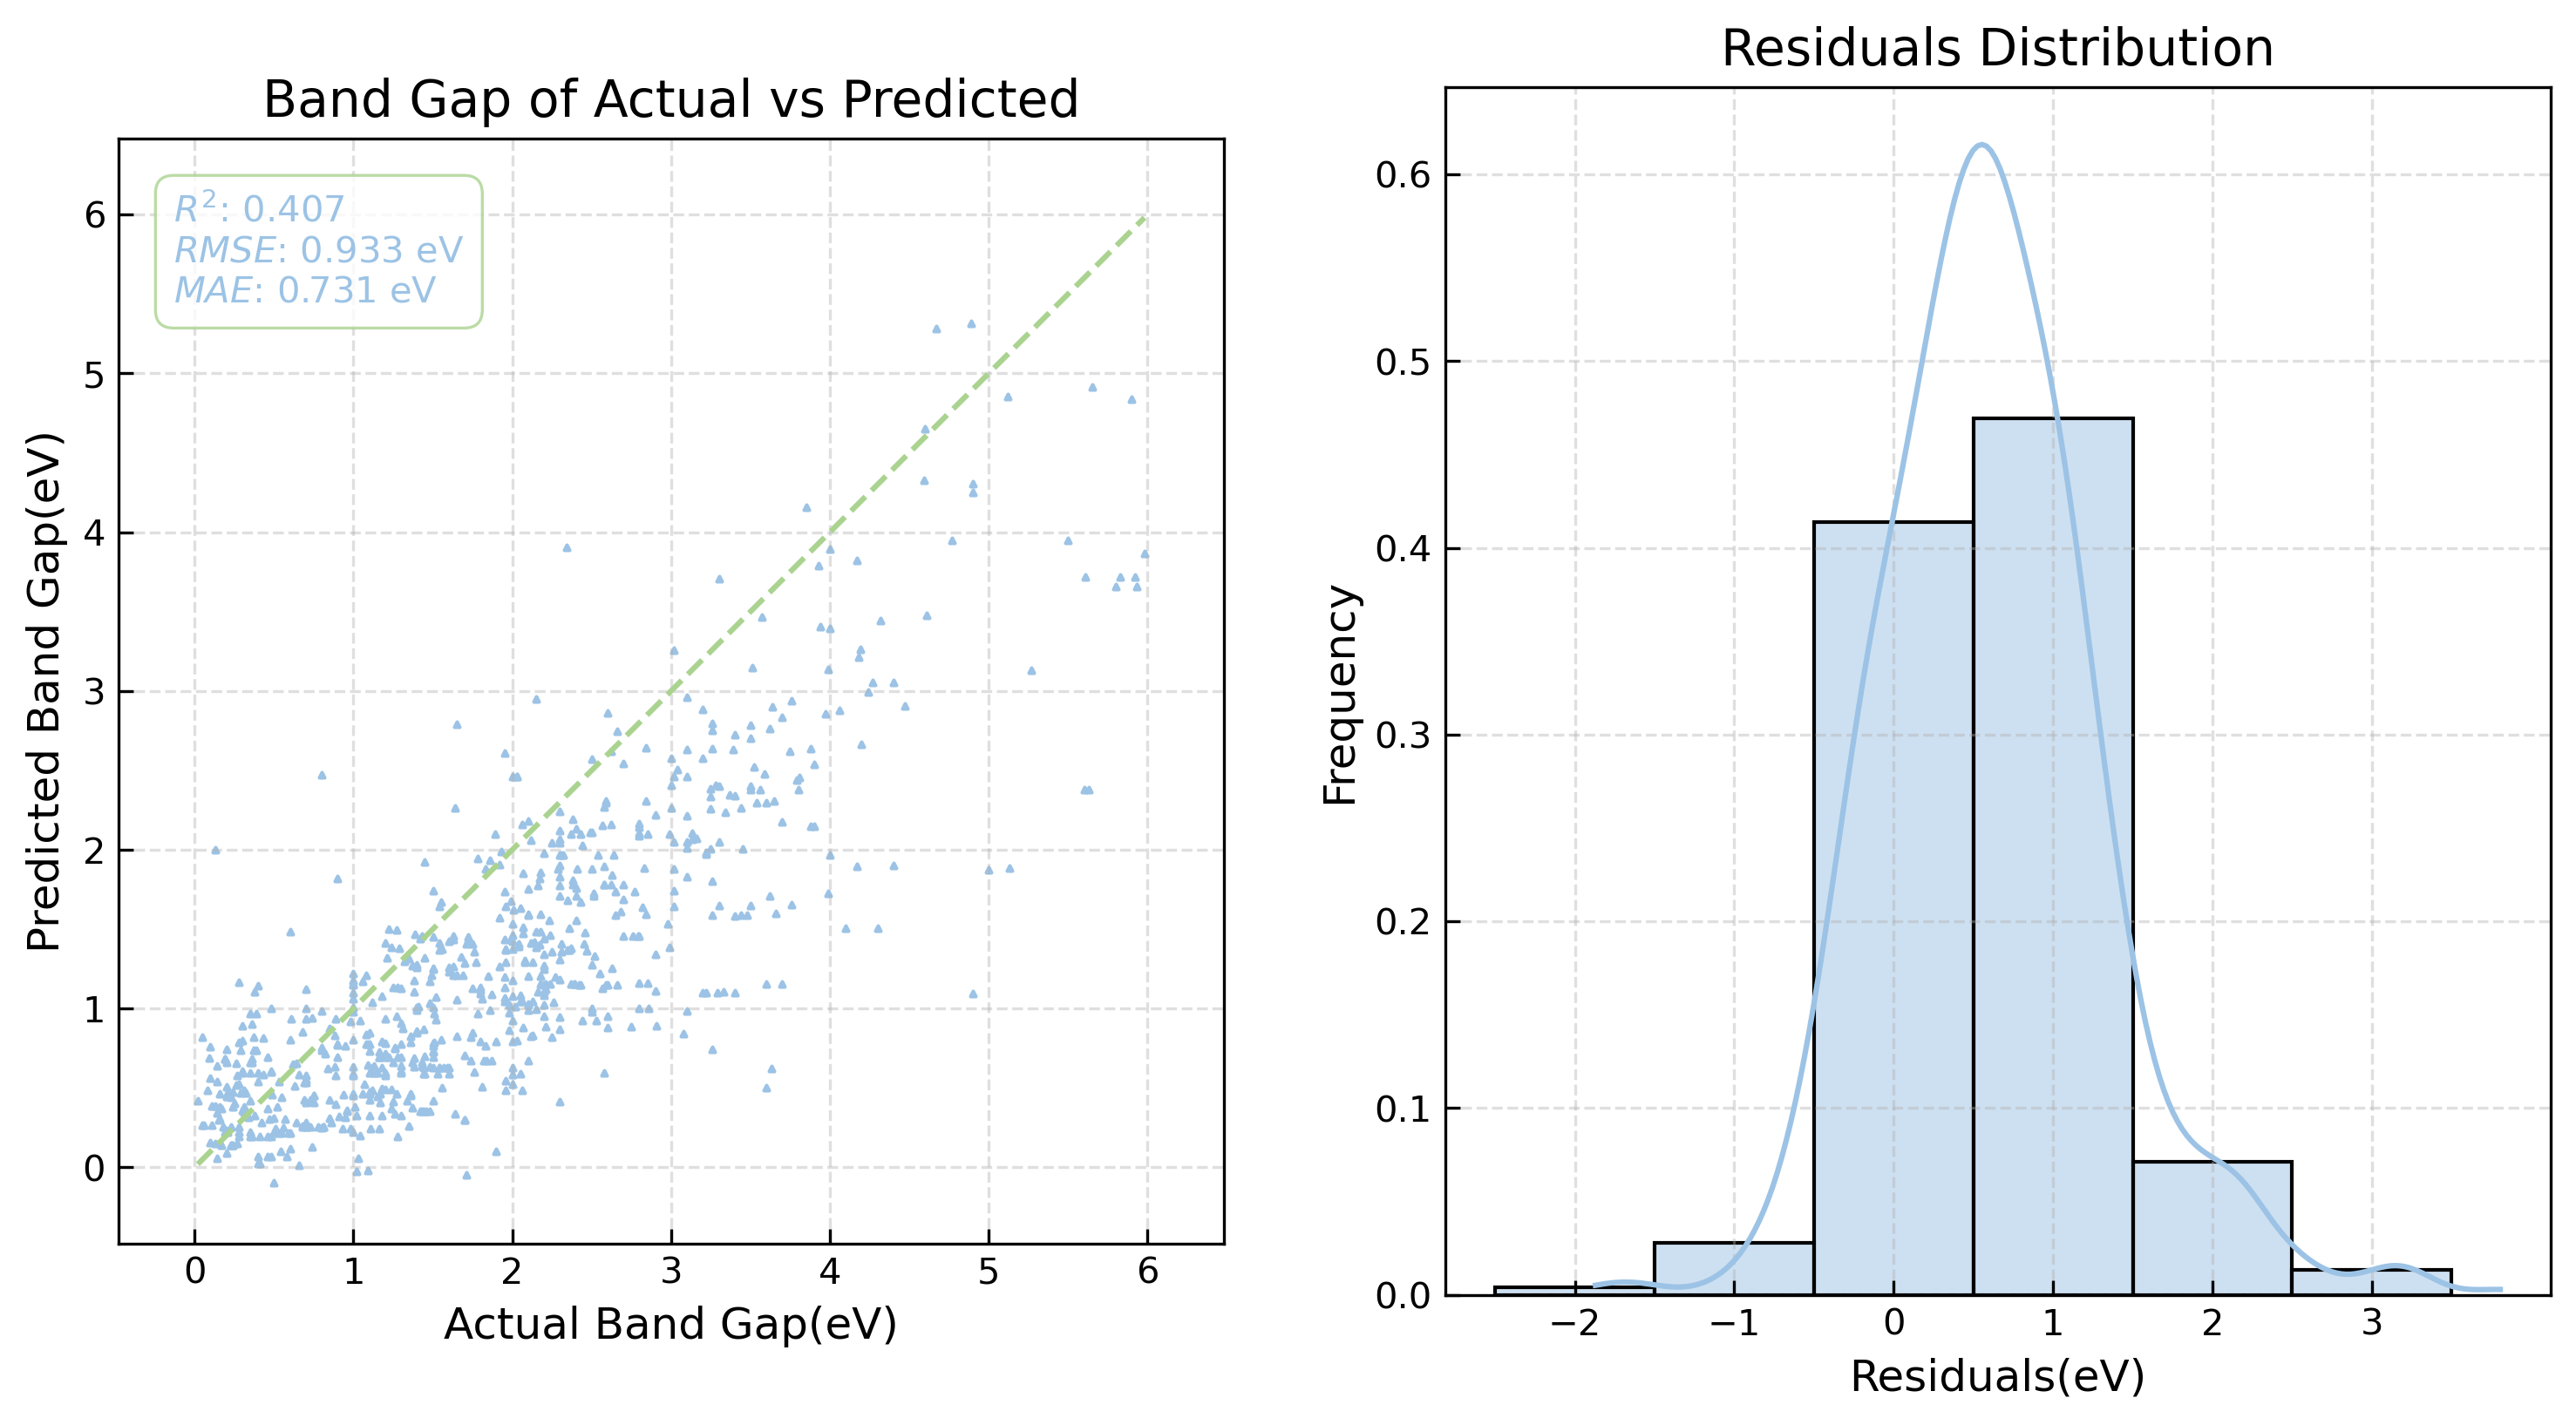


Model Evaluation Results:
Test set size: 757
Test set: R²: 0.4065 RMSE: 0.9332 MAE: 0.7306 MAPE: 56.6421%
[Test MIX -> MIX] Evaluating Direct Mix XGBoost on mixed test set:


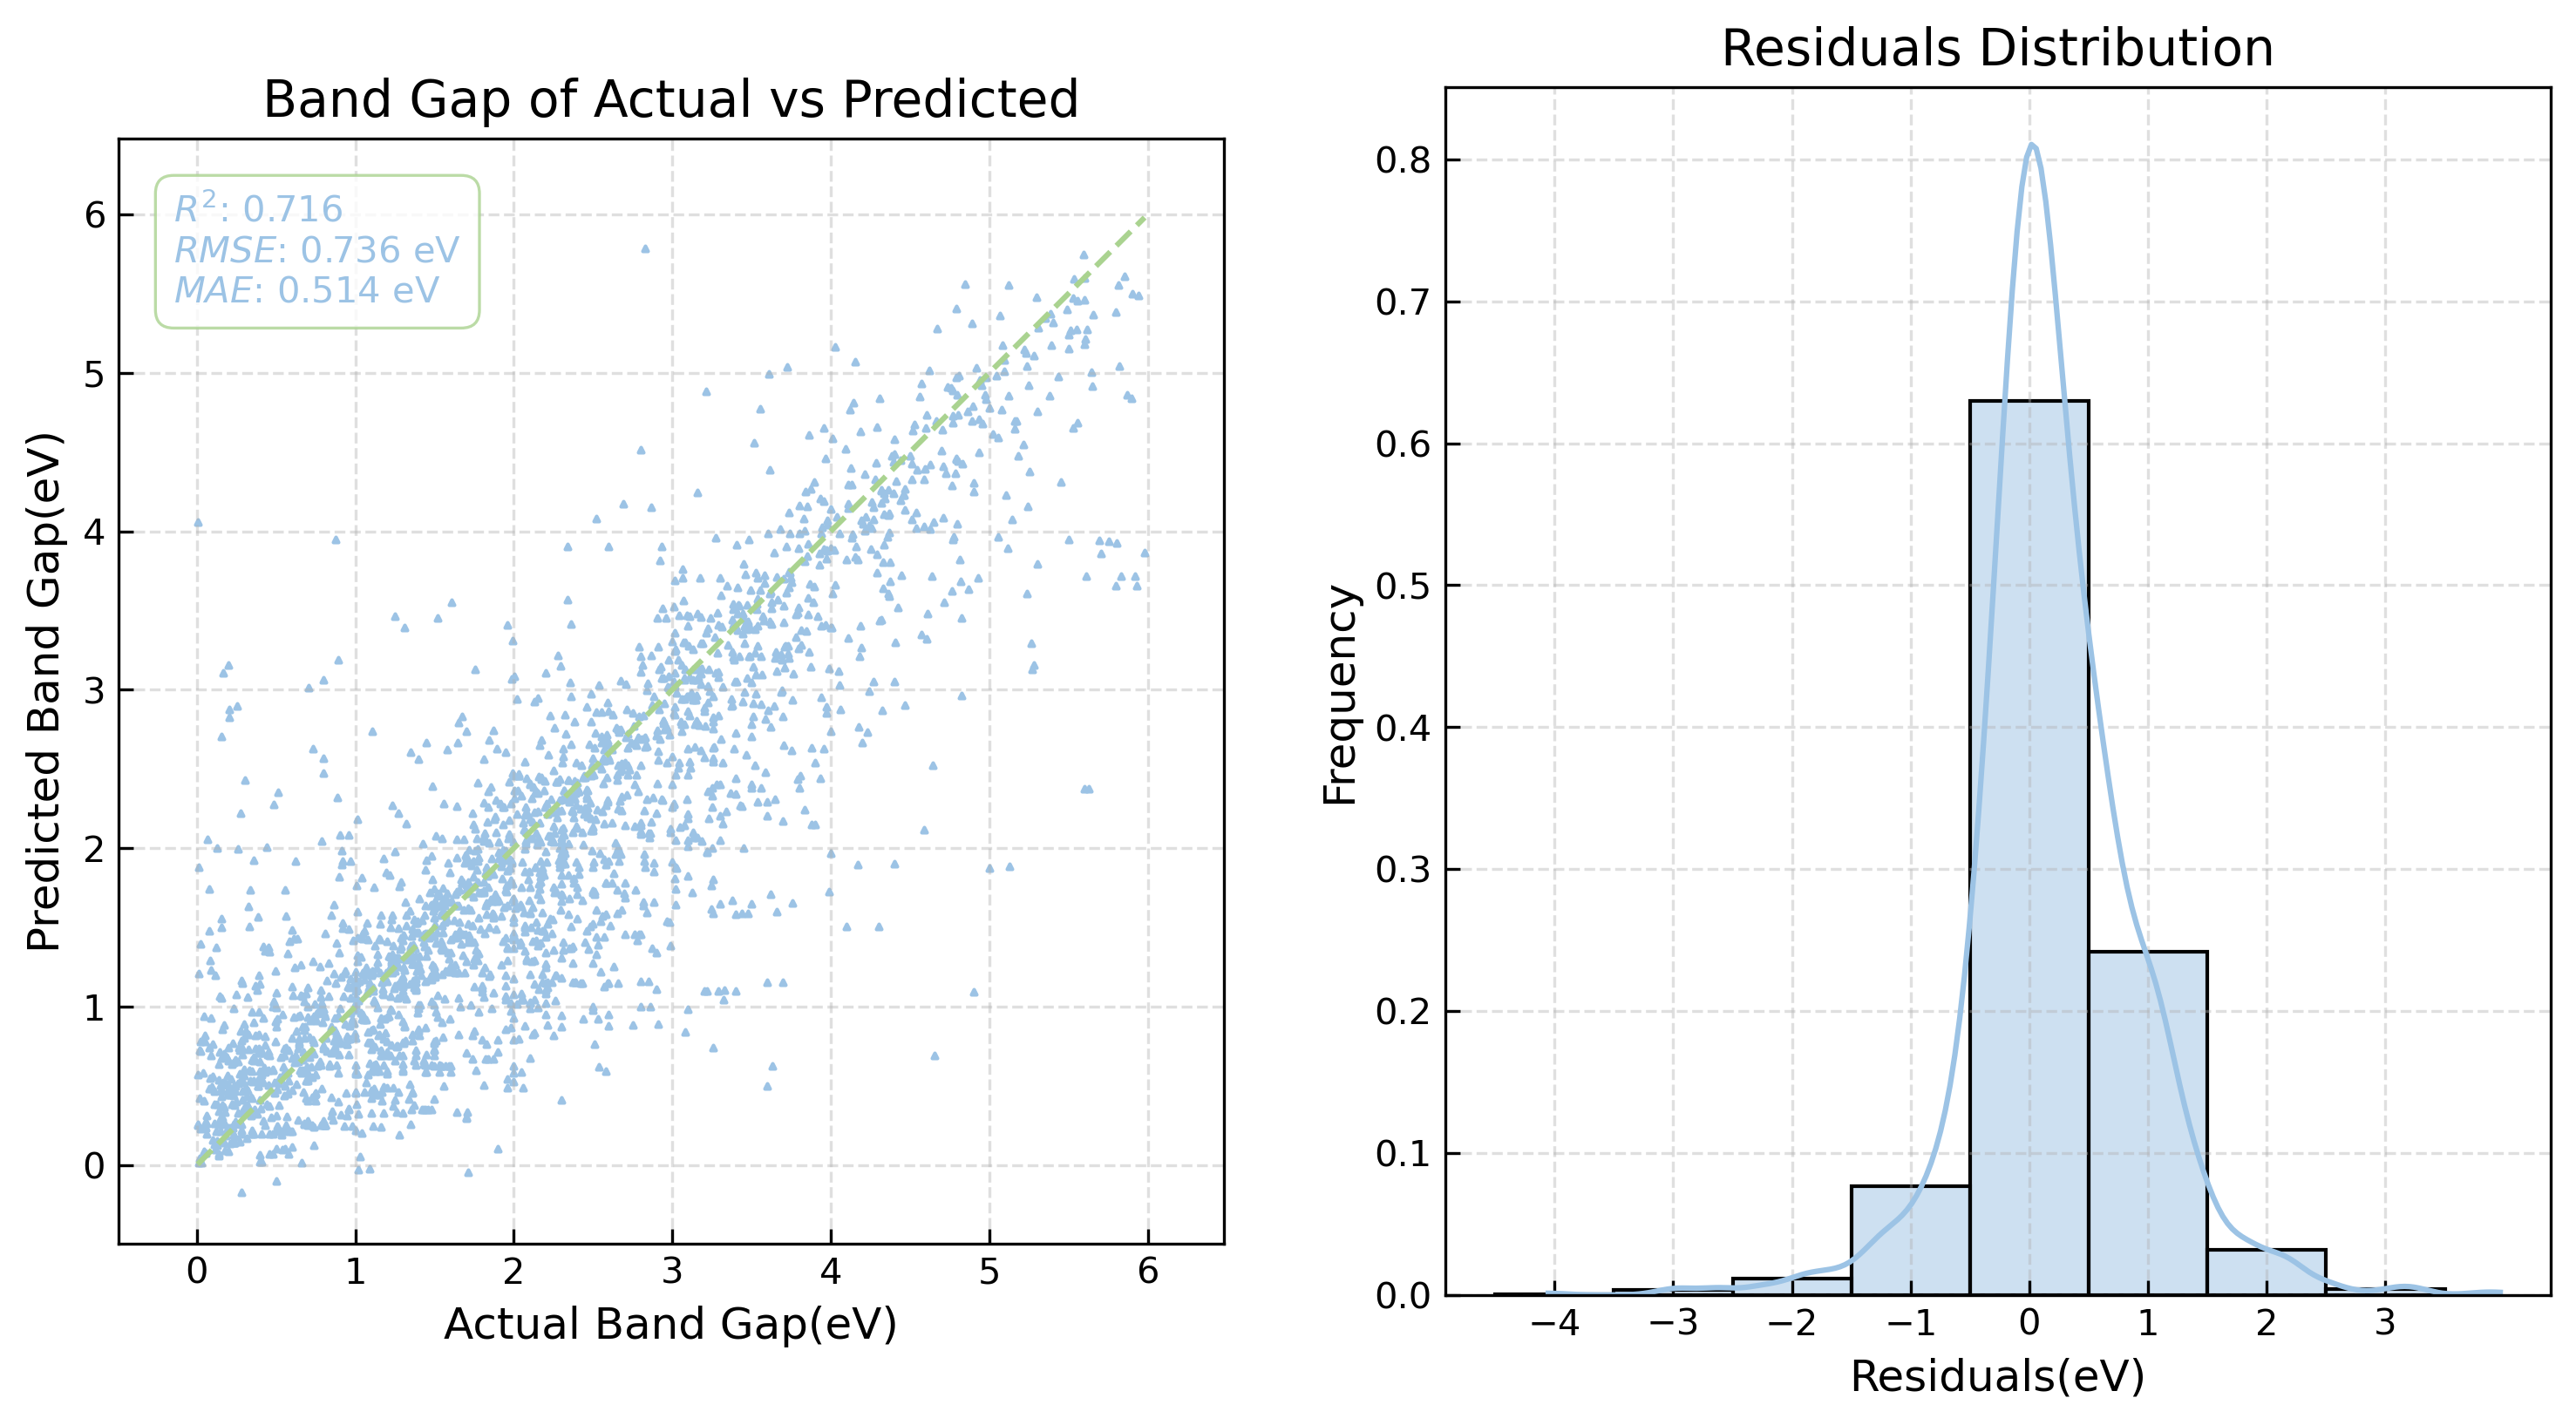


Model Evaluation Results:
Test set size: 2271
Test set: R²: 0.7164 RMSE: 0.7363 MAE: 0.5139 MAPE: 103.6234%


,Model,Error_Type,Train_set,Test_set,R²,RMSE,MAE
0,Direct Mix XGBoost,Train,mix,mix,0.915122,0.416122,0.246549
1,Direct Mix XGBoost,Test,mix,dft,0.820017,0.619787,0.400467
2,Direct Mix XGBoost,Test,mix,exp,0.406535,0.933236,0.730649
3,Direct Mix XGBoost,Test,mix,mix,0.716388,0.736325,0.513856


In [10]:
# 
MODEL_NAME = 'Direct Mix XGBoost'
# Train the model with the best hyperparameters on the entire training set
xgboost_best = XGBRegressor(learning_rate=0.1, max_depth=7, n_estimators=500,
    colsample_bytree=0.7, subsample=1.0, reg_lambda=0.5, alpha=0.5, 
    objective='reg:squarederror', random_state=RANDOM_SEED, n_jobs=-1)
# record model metrics
model_metrics = pd.DataFrame(columns=['Model', 'Error_Type', 'Train_set', 'Test_set', 'R²', 'RMSE', 'MAE'])
# Train the model on mixed data
print("#" * 100)
print(f"[DFT - {MODEL_NAME}] Training {MODEL_NAME} on Mix data:")
print("-" * 100)

model = SingleModel(xgboost_best, random_state=RANDOM_SEED)
model.train(dft_train_X, dft_train_y)

# evaluate on the train set
print(f"[Train_error] Evaluating {MODEL_NAME} on train set:")
metrics = model.evaluate(train_X, train_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,
'Error_Type': 'Train',
'Train_set': 'mix',
'Test_set': 'mix',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}

# evaluate on the dft test set
print(f"[Test MIX -> DFT] Evaluating {MODEL_NAME} on DFT test set:")

metrics = model.evaluate(dft_test_X, dft_test_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,
'Error_Type': 'Test',
'Train_set': 'mix',
'Test_set': 'dft',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}
# evaluate on the exp test set
print(f"[Test MIX -> EXP] Evaluating {MODEL_NAME} on EXP test set:")
metrics = model.evaluate(exp_test_X, exp_test_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,
'Error_Type': 'Test',
'Train_set': 'mix',
'Test_set': 'exp',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}

# evaluate on the mixed test set
print(f"[Test MIX -> MIX] Evaluating {MODEL_NAME} on mixed test set:")
metrics = model.evaluate(test_X, test_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,    
'Error_Type': 'Test',
'Train_set': 'mix',
'Test_set': 'mix',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}
# save the model metrics to a csv file
model_metrics.to_csv(os.path.join(file_path, 'model_metrics.csv'), index=False)
model_metrics